Contoh 2.1 MODEL REGRESSION TREES

In [11]:
import pandas as pd
import numpy as np

# Memasukkan keseluruhan data olahan
data_olahan = {'Temperatur': [80, 83, 68, 64, 69, 71, 78, 82, 73, 77],
               'Kelembapan': [90, 78, 80, 65, 70, 80, 75, 92, 88, 70],
               'Jumlah_Pemain': [39, 43, 28, 43, 56, 13, 51, 41, 29, 36]}
df = pd.DataFrame(data_olahan)

# Menampilkan data olahan
display(df)

# Melihat informasi dasar dari keseluruhan data olahan
df.info()

,Temperatur,Kelembapan,Jumlah_Pemain
0,80,90,39
1,83,78,43
2,68,80,28
3,64,65,43
4,69,70,56
5,71,80,13
6,78,75,51
7,82,92,41
8,73,88,29
9,77,70,36


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Temperatur     10 non-null     int64
 1   Kelembapan     10 non-null     int64
 2   Jumlah_Pemain  10 non-null     int64
dtypes: int64(3)
memory usage: 368.0 bytes


In [12]:
from sklearn.model_selection import train_test_split

# Penetapan variabel input dan variabel output
X, y = df.drop('Jumlah_Pemain', axis=1), df['Jumlah_Pemain']

# Splitting data olahan menjadi data latih dan data uji dengan perbandingan proporsi data 50%:50%
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.5, shuffle=False)

# Menampilkan seluruh sampel data dari data latih dan data uji, sesuai variabelnya.
display(X_train, y_train)
display(X_test, y_test)

,Temperatur,Kelembapan
0,80,90
1,83,78
2,68,80
3,64,65
4,69,70


0    39
1    43
2    28
3    43
4    56
Name: Jumlah_Pemain, dtype: int64

,Temperatur,Kelembapan
5,71,80
6,78,75
7,82,92
8,73,88
9,77,70


5    13
6    51
7    41
8    29
9    36
Name: Jumlah_Pemain, dtype: int64

In [13]:
# Mendefinisikan fungsi pencari nilai gain
def calculate_split_mse(X_train, y_train, feature_name, split_point):
    
    # Menyatakan data latih berdasarkan urutan variabel input
    datalatih_df = pd.DataFrame({'x_latih': X_train[feature_name],
                                 'y_latih': y_train}).sort_values('x_latih')
    
    # Mendefinisikan data yang dimuat simpul anak kiri dan kanan, sesuai titik pemisahan
    subset_kiri = datalatih_df['x_latih'] <= split_point
    rerataan_subset_kiri = datalatih_df[subset_kiri]['y_latih'].mean()
    rerataan_subset_kanan = datalatih_df[~subset_kiri]['y_latih'].mean()
    
    # Perhitungan kuadrat dari selisih sampel data x_latih dan y_latih
    datalatih_df['squared_diff'] = np.where(subset_kiri,
                                            (datalatih_df['y_latih'] - rerataan_subset_kiri) ** 2,
                                            (datalatih_df['y_latih'] - rerataan_subset_kanan) ** 2)
    
    # Perhitungan nilai impurity dari simpul anak kiri dan kanan
    impurity_subset_kiri = datalatih_df[subset_kiri]['squared_diff'].mean()
    impurity_subset_kanan = datalatih_df[~subset_kiri]['squared_diff'].mean()
    jumlah_data_subset_kiri = sum(subset_kiri)
    jumlah_data_subset_kanan = len(datalatih_df) - jumlah_data_subset_kiri
    
    # Perhitungan nilai gain
    gain = (jumlah_data_subset_kiri * impurity_subset_kiri + jumlah_data_subset_kanan * impurity_subset_kanan) / len(datalatih_df)
    
    # Print hasil perhitungan nilai gain
    display(datalatih_df)
    print(f"\nHasil dari pemisahan simpul induk pada [Titik Pemisahan(t_m)={split_point}] di dalam [Variabel Input(x_i): {feature_name}]:")
    print(f"Impurity Simpul Anak Kiri (Jumlah data={jumlah_data_subset_kiri}, Rerataan={rerataan_subset_kiri:.2f}): {impurity_subset_kiri:.2f}")
    print(f"Impurity Simpul Anak Kanan (Jumlah data={jumlah_data_subset_kanan}, Rerataan={rerataan_subset_kanan:.2f}): {impurity_subset_kanan:.2f}")
    print(f"Nilai Gain: {gain:.2f}")

# Contoh penggunaan fungsi pencari nilai gain pada kandidat pemisah tinjauan
calculate_split_mse(X_train, y_train, 'Temperatur', 66)

,x_latih,y_latih,squared_diff
3,64,43,0.00
2,68,28,182.25
4,69,56,210.25
0,80,39,6.25
1,83,43,2.25



Hasil dari pemisahan simpul induk pada [Titik Pemisahan(t_m)=66] di dalam [Variabel Input(x_i): Temperatur]:
Impurity Simpul Anak Kiri (Jumlah data=1, Rerataan=43.00): 0.00
Impurity Simpul Anak Kanan (Jumlah data=4, Rerataan=41.50): 100.25
Nilai Gain: 80.20


In [14]:
# Mendefinisikan fungsi pemisahan simpul secara greedy
def evaluate_all_splits(X_train, y_train):
    results = []
    
    for feature in X_train.columns:
        data = pd.DataFrame({'feature': X_train[feature], 'y_actual': y_train})
        titik_pemisahan = [(a + b)/2 for a, b in zip(sorted(data['feature'].unique())[:-1], sorted(data['feature'].unique())[1:])]
        
        for split in titik_pemisahan:
            subset_kiri = data['feature'] <= split
            jumlah_data_subset_kiri = sum(subset_kiri)
            
            if not (0 < jumlah_data_subset_kiri < len(data)): continue
                
            rerataan_subset_kiri = data[subset_kiri]['y_actual'].mean()
            rerataan_subset_kanan = data[~subset_kiri]['y_actual'].mean()
            
            impurity_subset_kiri = ((data[subset_kiri]['y_actual'] - rerataan_subset_kiri) ** 2).mean()
            impurity_subset_kanan = ((data[~subset_kiri]['y_actual'] - rerataan_subset_kanan) ** 2).mean()
            
            gain = (jumlah_data_subset_kiri * impurity_subset_kiri + (len(data) - jumlah_data_subset_kiri) * impurity_subset_kanan) / len(data)
            
            results.append({'Variabel Input': feature, 'Titik Pemisahan': split, 'Gain': gain})
    
    return pd.DataFrame(results).round(2)

# Contoh Penggunaan fungsi pemisahan simpul
results = evaluate_all_splits(X_train, y_train)
print(results)

  Variabel Input  Titik Pemisahan   Gain
0     Temperatur             66.0  80.20
1     Temperatur             68.5  54.10
2     Temperatur             74.5  80.13
3     Temperatur             81.5  80.20
4     Kelembapan             67.5  80.20
5     Kelembapan             74.0  41.03
6     Kelembapan             79.0  34.63
7     Kelembapan             85.0  78.60


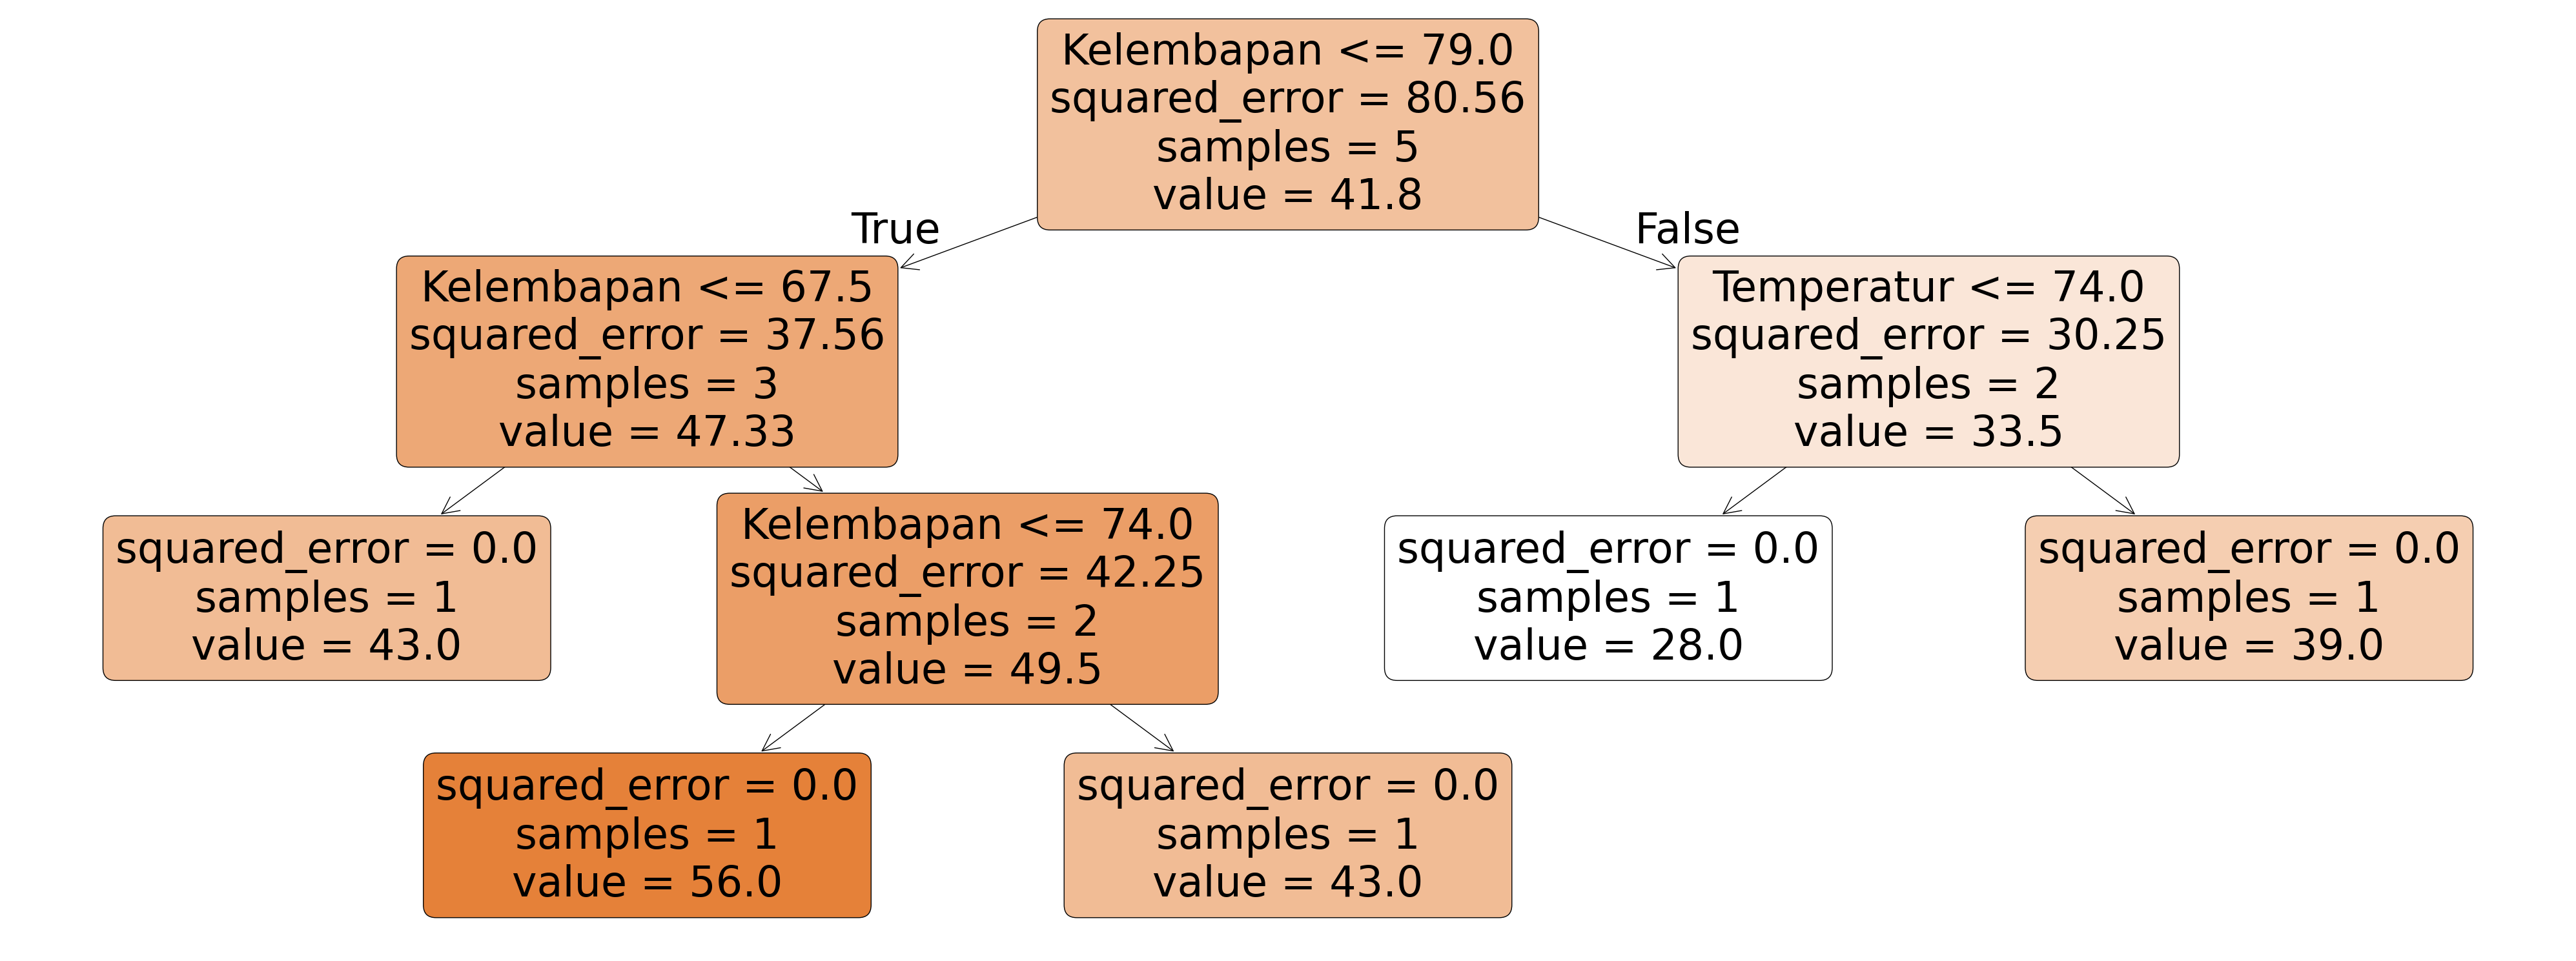

In [15]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

# Melatih Model Regression Tree
RegressionTree = DecisionTreeRegressor(random_state=42)
RegressionTree.fit(X_train, y_train)

# Visualisasi Regression Tree yang Terbentuk
plt.figure(figsize=(40,15))
plot_tree(RegressionTree,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          impurity=True,
          fontsize=47,
          precision=2)
plt.tight_layout()
plt.show()

In [16]:
# Melakukan prediksi Jumlah Pemain Golf
y_pred = RegressionTree.predict(X_test)

# Menampilkan hasil prediksi
print(y_pred)

[28. 43. 39. 28. 56.]


In [17]:
# Menampilkan perbandingan data hasil prediksi DT dan data aktual
df = pd.DataFrame(data={'Prediksi': y_pred, 'Aktual': y_test})
print(df)

   Prediksi  Aktual
5      28.0      13
6      43.0      51
7      39.0      41
8      28.0      29
9      56.0      36


In [18]:
from sklearn.metrics import root_mean_squared_error

# Evaluasi model DT dengan metrik RMSE
rmse = root_mean_squared_error(y_test, y_pred)
print(f'RMSE: {rmse:.4f}')

RMSE: 11.7813
